# Simload scenario comparison

In [2]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from teerex.analysis import (
    read_many_csv,
    infer_column,
    save_summary,
    plot_boxplot,
    plot_completion_throughput,
    TIME_CANDIDATES,
    EVENT_ID_CANDIDATES,
)

## Configure input files

Change `csv_glob` to point to your Simload CSV outputs.

In [3]:
#csv_glob = "../simload_runs/*.csv"
#csv_glob = "../simload_runs/out_g4_ray.csv"
#csv_glob = "../simload_runs/out_g4_ray_async.csv"
#csv_glob = "../simload_runs/mode_async.csv"

outdir = Path("../simload_analysis")
outdir.mkdir(parents=True, exist_ok=True)
#csv_files = sorted(Path(".").glob(csv_glob))

csv_files = []

#csv_files.append(Path('../simload_runs/mode_async.csv'))
#csv_files.append(Path('../simload_runs/mode_blocking.csv'))

csv_files.append(Path('../simload_runs/comparison/async.csv'))
csv_files.append(Path('../simload_runs/comparison/blocking.csv'))
csv_files.append(Path('../simload_runs/comparison/event_barrier.csv'))

csv_files

[PosixPath('../simload_runs/comparison/async.csv'),
 PosixPath('../simload_runs/comparison/blocking.csv'),
 PosixPath('../simload_runs/comparison/event_barrier.csv')]

## Load and combine CSV files

In [4]:
df = read_many_csv(csv_files)
df.to_csv(outdir / "combined.csv", index=False)

print(f"rows: {len(df)}")
print(f"runs: {df['scenario'].nunique()}")
df.head()

rows: 60
runs: 3


,event_id,event_size_s,cpu_fraction,gpu_fraction,cpu_work_s,gpu_work_s,dispatch_fraction,cpu_pre_work_s,cpu_post_work_s,cpu_matrix_size,...,gpu_start_time_offset_s,gpu_end_time_offset_s,gpu_wait_start_time_offset_s,gpu_wait_end_time_offset_s,merge_start_time_offset_s,merge_end_time_offset_s,start_offset_s,end_offset_s,scenario,source_file
0,0,2.925720,0.687906,0.312094,2.012620,0.913099,0.513202,1.032880,0.979740,726,...,1.149805,2.186031,29.124172,29.124183,29.124185,29.134271,0.084324,29.134271,async,../simload_runs/comparison/async.csv
1,1,2.041947,0.359294,0.640706,0.733660,1.308287,0.599125,0.439554,0.294106,438,...,2.589771,3.915121,29.134295,29.134303,29.134304,29.144968,2.147841,29.144968,async,../simload_runs/comparison/async.csv
2,2,2.317153,0.579108,0.420892,1.341881,0.975272,0.468111,0.628149,0.713732,593,...,3.920787,4.902889,29.144987,29.144994,29.144995,29.159785,2.888869,29.159785,async,../simload_runs/comparison/async.csv
3,3,3.973224,0.560057,0.439943,2.225232,1.747992,0.523964,1.165941,1.059290,763,...,5.434830,7.191047,29.159802,29.159809,29.159811,29.170752,4.261862,29.170752,async,../simload_runs/comparison/async.csv
4,4,3.806892,0.560379,0.439621,2.133304,1.673588,0.544742,1.162100,0.971204,747,...,7.678780,9.361405,29.170759,29.170761,29.170762,29.180818,6.511872,29.180818,async,../simload_runs/comparison/async.csv


In [5]:
df.columns

Index(['event_id', 'event_size_s', 'cpu_fraction', 'gpu_fraction',
       'cpu_work_s', 'gpu_work_s', 'dispatch_fraction', 'cpu_pre_work_s',
       'cpu_post_work_s', 'cpu_matrix_size', 'gpu_matrix_size',
       'gpu_memory_mb', 'h2d_mb', 'd2h_mb', 'num_cpus', 'num_gpus', 'stage',
       'gpu_mode', 'gpu_async', 'start_time', 'end_time', 'runtime_s',
       'cpu_start_time', 'cpu_end_time', 'cpu_runtime_s', 'cpu_pre_start_time',
       'cpu_pre_end_time', 'cpu_pre_runtime_s', 'cpu_pre_iterations',
       'cpu_post_start_time', 'cpu_post_end_time', 'cpu_post_runtime_s',
       'cpu_post_iterations', 'gpu_submit_time', 'gpu_start_time',
       'gpu_end_time', 'gpu_runtime_s', 'gpu_queue_delay_s', 'gpu_iterations',
       'gpu_wait_start_time', 'gpu_wait_end_time', 'gpu_wait_runtime_s',
       'merge_start_time', 'merge_end_time', 'merge_runtime_s',
       'start_time_offset_s', 'end_time_offset_s', 'cpu_start_time_offset_s',
       'cpu_end_time_offset_s', 'cpu_pre_start_time_offset_s',


## Generate comparison plots

The plot functions save PNG files into `outdir`.

In [6]:
def plot_run_timeline(
    df: pd.DataFrame,
    run: str | list[str],
    outdir: Path | None = None,
    filename: str | None = None,
    figsize: tuple[float, float] | None = None,
):
    single_run = isinstance(run, str)
    runs = [run] if single_run else list(run)
    if not runs:
        raise ValueError("run must contain at least one run label")

    columns = [
        "scenario",
        "event_id",
        "cpu_start_time",
        "cpu_end_time",
        "gpu_start_time",
        "gpu_end_time",
    ]
    optional_columns = [
        "cpu_pre_start_time",
        "cpu_pre_end_time",
        "cpu_post_start_time",
        "cpu_post_end_time",
        "gpu_submit_time",
    ]
    columns = columns + [col for col in optional_columns if col in df.columns]
    available_runs = sorted(df["scenario"].dropna().unique())
    missing_runs = [run_label for run_label in runs if run_label not in available_runs]
    if missing_runs:
        raise ValueError(f"Run labels not found: {missing_runs}. Available runs: {available_runs}")

    def build_run_timeline(run_label: str) -> pd.DataFrame:
        run_timeline = df.loc[df["scenario"].eq(run_label), columns].dropna().copy()
        if run_timeline.empty:
            raise ValueError(f"No complete timeline rows found for run={run_label!r}")

        time_origin = run_timeline[["cpu_start_time", "gpu_start_time"]].min().min()
        time_columns = [
            "cpu_start_time",
            "cpu_end_time",
            "gpu_start_time",
            "gpu_end_time",
            "cpu_pre_start_time",
            "cpu_pre_end_time",
            "cpu_post_start_time",
            "cpu_post_end_time",
            "gpu_submit_time",
        ]
        for col in [col for col in time_columns if col in run_timeline.columns]:
            run_timeline[f"{col}_offset_s"] = run_timeline[col] - time_origin

        return run_timeline.sort_values("event_id").reset_index(drop=True)

    run_timelines = [build_run_timeline(run_label) for run_label in runs]
    timeline = pd.concat(run_timelines, ignore_index=True)
    x_max = timeline[["cpu_end_time_offset_s", "gpu_end_time_offset_s"]].max().max()
    x_limit = x_max * 1.02 if x_max > 0 else 1.0

    if figsize is None:
        figsize = (11, 3 * len(runs))

    resource_y = {"GPU": 0, "CPU": 1}
    fig, axes = plt.subplots(len(runs), 1, figsize=figsize, sharex=True, squeeze=False)
    axes = axes.ravel()

    for ax, run_label, run_timeline in zip(axes, runs, run_timelines):
        event_starts = run_timeline["cpu_start_time_offset_s"].dropna().sort_values().unique()
        for event_start in event_starts:
            ax.axvline(event_start, color="0.2", linewidth=0.8, alpha=0.5, zorder=0)

        labels_drawn = {"CPU": False, "GPU": False}

        for _, row in run_timeline.iterrows():
            cpu_segments = []
            if {"cpu_pre_start_time_offset_s", "cpu_pre_end_time_offset_s", "cpu_post_start_time_offset_s", "cpu_post_end_time_offset_s"} <= set(run_timeline.columns):
                cpu_segments = [
                    (row["cpu_pre_start_time_offset_s"], row["cpu_pre_end_time_offset_s"]),
                    (row["cpu_post_start_time_offset_s"], row["cpu_post_end_time_offset_s"]),
                ]
            else:
                cpu_segments = [(row["cpu_start_time_offset_s"], row["cpu_end_time_offset_s"])]

            for cpu_start, cpu_end in cpu_segments:
                ax.hlines(
                    resource_y["CPU"],
                    cpu_start,
                    cpu_end,
                    color="tab:blue",
                    linewidth=10,
                    label="CPU busy" if not labels_drawn["CPU"] else "_nolegend_",
                )
                labels_drawn["CPU"] = True
            ax.hlines(
                resource_y["GPU"],
                row["gpu_start_time_offset_s"],
                row["gpu_end_time_offset_s"],
                color="tab:orange",
                linewidth=10,
                label="GPU busy" if not labels_drawn["GPU"] else "_nolegend_",
            )
            labels_drawn["GPU"] = True

        ax.set_title(f"{run_label} CPU/GPU busy timeline")
        ax.set_ylabel("resource")
        ax.set_yticks([resource_y["GPU"], resource_y["CPU"]])
        ax.set_yticklabels(["GPU", "CPU"])
        ax.set_ylim(-0.6, 1.6)
        ax.set_xlim(0, x_limit)
        ax.grid(True, alpha=0.3)
        ax.legend(loc="upper right")

    axes[-1].set_xlabel("time since first stage start in each run (s)")

    fig.tight_layout()
    if outdir is not None:
        outdir.mkdir(parents=True, exist_ok=True)
        if filename is None:
            filename = f"{'_'.join(runs)}_cpu_gpu_busy_intervals.png"
        fig.savefig(outdir / filename, dpi=160)

    return fig, axes[0] if single_run else axes, timeline

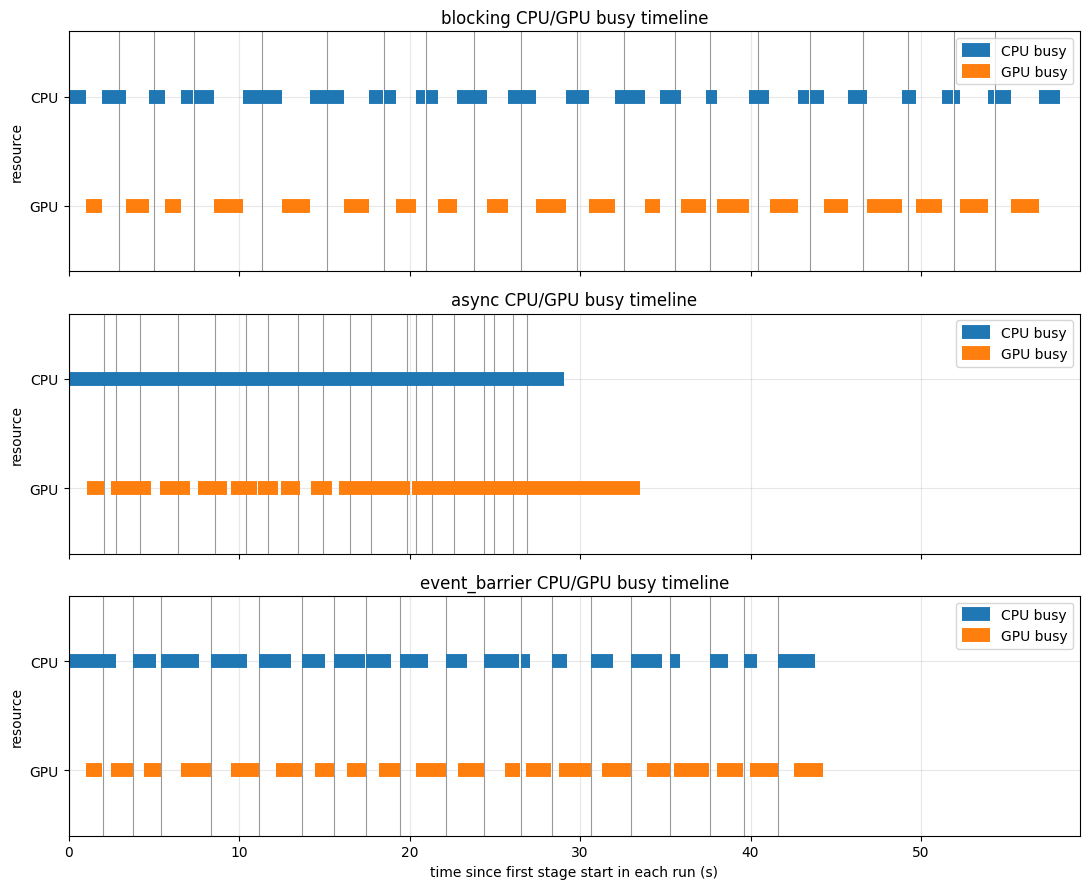

In [7]:
#fig, axes, run_timelines = plot_run_timeline(df, ["mode_async", "mode_blocking"])
fig, axes, run_timelines = plot_run_timeline(df, ["blocking", "async", "event_barrier"])
# fig, ax, run_timeline = plot_run_timeline(df, "mode_async")